In [1]:
%matplotlib widget
import numpy as np
from numpy import abs
import matplotlib.pyplot as plt
from scipy.special import eval_genlaguerre
import ipywidgets as widgets

There is no analytical expression for the Classical Fisher Information in the case of seeded parametric down-conversion. Instead it is necessary to compute it as

\begin{equation}
F_C=\sum_m\frac{1}{p_m}\left(\frac{\partial p_m}{\partial\varphi}\right)^2,
\end{equation}

where the analytical expressions of both $p_m$ and $\partial p_m/\partial\varphi$ are known (eqs. 4.19 and 4.20 in thesis manuscript, respectively). Next some quantities of interest are plotted as a widget, so that is possible to observe how they react to varying the relevant parameters.


NOTE: In order to use the sliders, run each widget code at a time.

NOTE: If one dynamic widget is not working, run its cell again.

### Laguerre Polynomials in $p_m$ expression

interactive(children=(FloatSlider(value=1.0, description='m:', step=1.0), FloatLogSlider(value=1.0, descriptio…

<function __main__.update_plot_1(m=10, G=1, a_i=0, t_i1=1, t_s1=1, t_s2=1)>

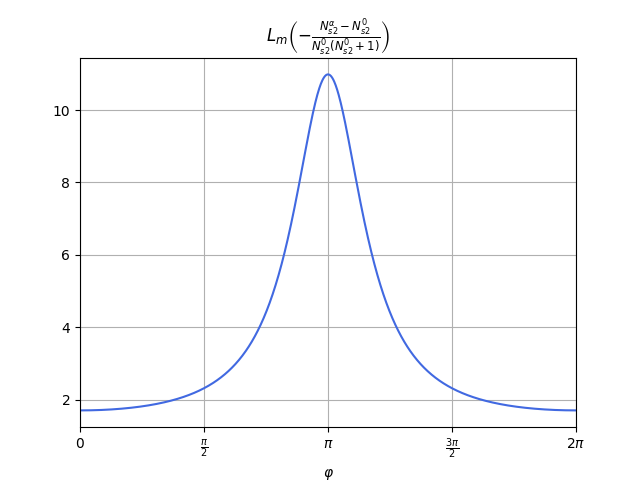

In [2]:
phi=np.linspace(0,2*np.pi,1000)              #? φ

fig1,ax1 = plt.subplots()
line, = ax1.plot([], [], color="royalblue")
ax1.grid(True)

ax1.set_xlim([0, 2*np.pi])
ax1.set_xticks(np.linspace(0, 2*np.pi, 5))
ax1.set_xticklabels([0, r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"])
ax1.set_xlabel(r'$\varphi$')
ax1.set_title(r"$L_m\left(-\frac{N_{s2}^{\alpha}-N_{s2}^0}{N_{s2}^0(N_{s2}^0+1)}\right)$")


def L_poly(m, phi=phi, G=0.5, a_i=0, t_s1=1, t_i1=1, t_s2=1): 
    '''
    #?  Laguerre Polynomials inside the probability distribution expression p_m
    '''
    
    U=np.cosh(G)
    V=np.sinh(G)
    
    #* Average number of output signal photons (no seed): <N_{s2}^{α=0}>
    N0 = abs(t_s2)**2*abs(V)**2*  \
        (1-abs(t_i1)**2+abs(U)**2*(abs(t_s1)**2+abs(t_i1)**2+
        2*abs(t_s1)*abs(t_i1)*np.cos(phi)))    

    #* Average number of output signal photons (seed): <N_{s2}^{α}>
    Na= abs(t_s2)**2*abs(V)**2*  \
        (1-abs(t_i1)**2+(1+abs(a_i)**2)*abs(U)**2*(abs(t_s1)**2+abs(t_i1)**2+
        2*abs(t_s1)*abs(t_i1)*np.cos(phi))) 
    
    x = (Na-N0)/(N0*(N0+1))
    
    L = eval_genlaguerre(m,0,-x)

    return L

def update_plot_1(m=10, G=1, a_i=0, t_i1=1, t_s1=1, t_s2=1):
    L=L_poly(m, G=G, a_i=a_i, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2)
    line.set_data(phi,L)
    ax1.relim()
    ax1.autoscale_view()
    fig1.canvas.draw()

m = widgets.FloatSlider(value=1, min=0, max=100, step=1, description='m:')              #? Polynomial Order
G = widgets.FloatLogSlider(value=1, base=10, min=-1, max=1, step=0.1, description='G:')
a_i = widgets.FloatSlider(value=3.16, min=0, max=10, step=0.01, description='α:')   
t_i1 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='τᵢ₁:')       
t_s1 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='τₛ₁:')          
t_s2 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='τₛ₂:')          
         
widgets.interact(update_plot_1, m=m, G=G, a_i=a_i, t_i1=t_i1, t_s1=t_s1, t_s2=t_s2)

### Probability Distribution $p_m$

interactive(children=(FloatSlider(value=200.0, description='n:', max=500.0, min=10.0, step=10.0), FloatSlider(…

<function __main__.update_plot_2(mMax=10, phi=1.5707963267948966, G=1, a_i=0, t_i1=1, t_s1=1, t_s2=1)>

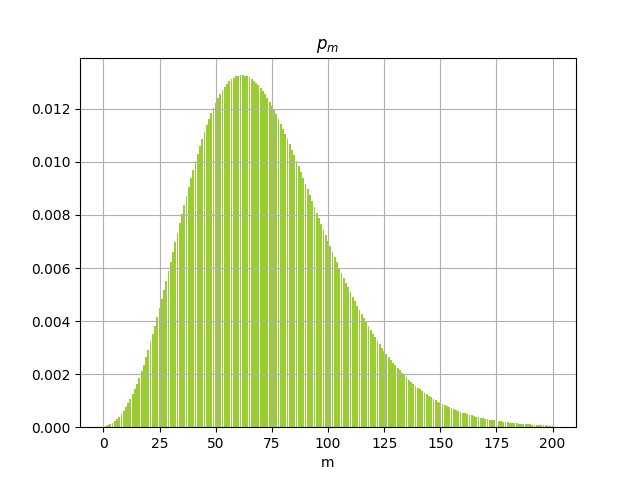

In [3]:
fig2,ax2 = plt.subplots()

def P_m(mMax, phi=np.pi/2, G=0.5, a_i=0, t_s1=1, t_i1=1, t_s2=1): 
    '''
    #? Probability Dist. 
    #? p_m(φ=π) = δ_{0,m} (computationally verified by removing φ slider and setting φ=π)
    '''
    
    U=np.cosh(G)
    V=np.sinh(G)
    
    #* Average number of output signal photons (no seed): <N_{s2}^{α=0}>
    N0 = abs(t_s2)**2*abs(V)**2*  \
        (1-abs(t_i1)**2+abs(U)**2*(abs(t_s1)**2+abs(t_i1)**2+
        2*abs(t_s1)*abs(t_i1)*np.cos(phi)))    

    #* Average number of output signal photons (seed): <N_{s2}^{α}>
    Na= abs(t_s2)**2*abs(V)**2*  \
        (1-abs(t_i1)**2+(1+abs(a_i)**2)*abs(U)**2*(abs(t_s1)**2+abs(t_i1)**2+
        2*abs(t_s1)*abs(t_i1)*np.cos(phi))) 
    
    if phi==np.pi:
        x=a_i**2        #? Limit
    else:
        x = (Na-N0)/(N0*(N0+1)) 
    m = np.arange(mMax+1)
    
    P = 1/(1+N0)*(N0/(1+N0))**m * np.exp(-N0*x) * eval_genlaguerre(m,0,-x)

    return P

def update_plot_2(mMax=10, phi=np.pi/2, G=1, a_i=0, t_i1=1, t_s1=1, t_s2=1):
    P=P_m(mMax, phi=phi, G=G, a_i=a_i, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2)
    ax2.cla()
    ax2.bar(np.arange(mMax+1),P,color="yellowgreen")
    ax2.set_xlabel('m')
    ax2.set_title(r'$p_m$')
    ax2.grid(True)

mMax = widgets.FloatSlider(value=200, min=10, max=500, step=10, description='n:')           #? Max Probability displayed
phi = widgets.FloatSlider(value=np.pi/2, min=0, max=np.pi, step=0.1, description='φ:')
G = widgets.FloatLogSlider(value=1, base=10, min=-1, max=1, step=0.1, description='G:')
t_i1 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='τᵢ₁:')
t_s1 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='τₛ₁:')
t_s2 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='τₛ₂:')
a_i = widgets.FloatSlider(value=3.16, min=0, max=10, step=0.01, description='α:')

widgets.interact(update_plot_2, mMax=mMax, phi=phi, G=G, a_i=a_i, t_i1=t_i1, t_s1=t_s1, t_s2=t_s2)

### Derivative $\frac{\partial p_m}{\partial \varphi}$

In order to compute the derivative $\frac{\partial p_m}{\partial \varphi}$ (eq. 4.20 in manuscript), it is necessary to first compute the quantity $\frac{\partial \langle N_{s2}^0\rangle/\partial \varphi}{\langle N_{s2}^0\rangle^2}$. This quantity is known analitically, but it has an indeterminacy 0/0 at $\varphi=\pi$. Then, a simple test to numerically prove that $\lim_{\varphi\to\pi}\frac{\partial \langle N_{s2}^0\rangle/\partial \varphi}{\langle N_{s2}^0\rangle^2}=0$ is presented before the derivative $\frac{\partial p_m}{\partial \varphi}$ is computed.

Text(0.5, 1.0, '$\\frac{\\partial \\langle N_{s2}^0\\rangle\\ /\\ \\partial\\varphi}{ \\langle N_{s2}^0\\rangle^2}$')

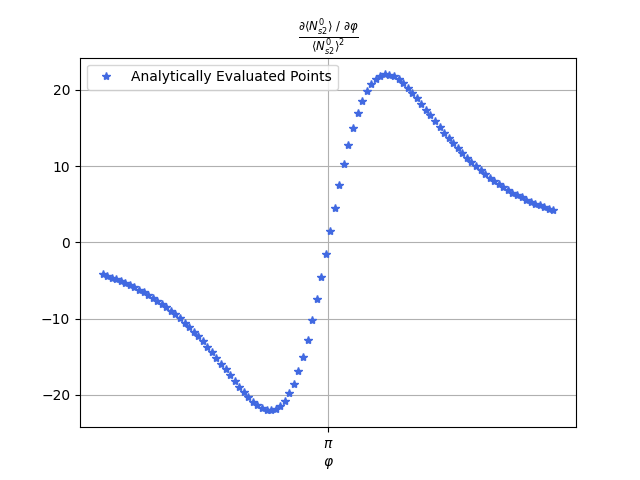

In [4]:
rng=np.random.default_rng()

def test(phi, G=1, t_s1=1, t_i1=1, t_s2=1): 
    """"   
    #? At φ=π, dN0 / N0^2 = 0/0 . However, this expression is needed to evaluate d/dφ(p_m),
    #? which is why it is necessary to determine what the limit is. This task is difficcult to 
    #? tackle analytically, which is why a numerical test is carried out.

    #? It can be observed that as long as there are losses, when φ->π, lim dN0 / N0^2 = 0
    """
    U=np.cosh(G)
    V=np.sinh(G)
    
    #* Average number of output signal photons (no seed): <N_{s2}^{α=0}>
    N0 = abs(t_s2)**2*abs(V)**2*  \
        (1-abs(t_i1)**2+abs(U)**2*(abs(t_s1)**2+abs(t_i1)**2+
        2*abs(t_s1)*abs(t_i1)*np.cos(phi))) 
        
    #* d/dφ ( <N_{s2}^{α=0}> )    
    dN0 = -2* abs(t_s1) * abs(t_i1) * abs(t_s2)**2 * abs(V)**2 * abs(U)**2 * np.sin(phi)
    
    return dN0/N0**2

phi=np.linspace(np.pi-0.5,np.pi+0.5,100)
#y = test(phi, G=1, t_s1=rng.random(), t_i1=rng.random(), t_s2=rng.random())   #? Shows same conclussion
y = test(phi, G=1, t_s1=0.8) 

fig3,ax3 = plt.subplots()
ax3.plot(phi, y, '*',color="royalblue", label='Analytically Evaluated Points')
ax3.legend()

ax3.set_xticks([np.pi])
ax3.set_xticklabels([r'$\pi$'])
ax3.set_xlabel(r'$\varphi$')
ax3.grid(True)

ax3.set_title(r"$\frac{\partial \langle N_{s2}^0\rangle\ /\ \partial\varphi}{ \langle N_{s2}^0\rangle^2}$")


interactive(children=(FloatSlider(value=200.0, description='n:', max=500.0, min=10.0, step=10.0), FloatSlider(…

<function __main__.update_plot(mMax=10, phi=1.5707963267948966, G=1, a_i=0, t_i1=1, t_s1=1, t_s2=1)>

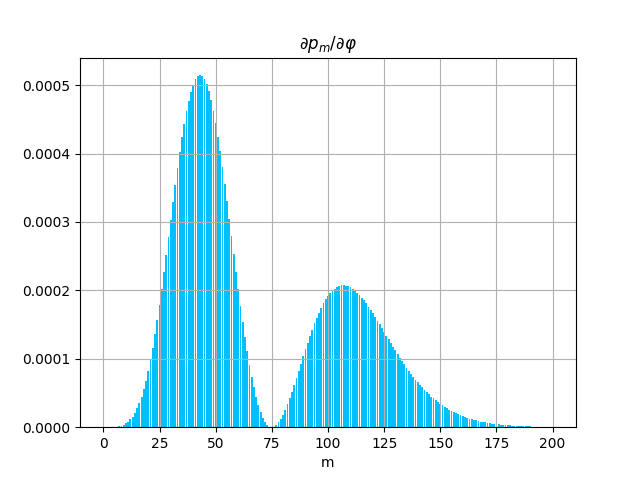

In [5]:
fig4,ax4 = plt.subplots()

def dPm_dphi(mMax, phi=np.pi/2, G=0.5, a_i=0, t_s1=1, t_i1=1, t_s2=1): 
    '''
    #? φ derivative of the probability distribution p_m.
    '''
    
    U=np.cosh(G)
    V=np.sinh(G)
    
    #* Average number of output signal photons (no seed): <N_{s2}^{α=0}>
    N0 = abs(t_s2)**2*abs(V)**2*  \
        (1-abs(t_i1)**2+abs(U)**2*(abs(t_s1)**2+abs(t_i1)**2+
        2*abs(t_s1)*abs(t_i1)*np.cos(phi)))    

    #* Average number of output signal photons (seed): <N_{s2}^{α}>
    Na= abs(t_s2)**2*abs(V)**2*  \
        (1-abs(t_i1)**2+(1+abs(a_i)**2)*abs(U)**2*(abs(t_s1)**2+abs(t_i1)**2+
        2*abs(t_s1)*abs(t_i1)*np.cos(phi))) 
    
    #* d/dφ ( <N_{s2}^{α=0}> )    
    dN0 = -2* abs(t_s1) * abs(t_i1) * abs(t_s2)**2 * abs(V)**2 * abs(U)**2 * np.sin(phi)
        
    if phi==np.pi:
        x=a_i**2        #? Limit, analytical
    else:
        x = (Na-N0)/(N0*(N0+1))
    m = np.arange(mMax+1)
    P = 1/(1+N0)*(N0/(1+N0))**m * np.exp(-N0*x) * eval_genlaguerre(m,0,-x)

    if N0!=0:
        dPm = P * dN0/N0**2 * (
                N0/(1+N0)*(abs(a_i)**2-x*(2*N0+1))*(eval_genlaguerre(m-1,1,-x)/eval_genlaguerre(m,0,-x)+1)
                -N0*(2+abs(a_i)**2-(1+m)/(1+N0)) +Na  ) 
    else:
        dPm = P *     0     * (
                N0/(1+N0)*(abs(a_i)**2-x*(2*N0+1))*(eval_genlaguerre(m-1,1,-x)/eval_genlaguerre(m,0,-x)+1)
                -N0*(2+abs(a_i)**2-(1+m)/(1+N0)) + Na  )         #? Limit, Numerical
        
    return dPm

def update_plot(mMax=10, phi=np.pi/2, G=1, a_i=0, t_i1=1, t_s1=1, t_s2=1):
    dP=dPm_dphi(mMax, phi=phi, G=G, a_i=a_i, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2)
    ax4.cla()
    ax4.bar(np.arange(mMax+1),dP**2,color="deepskyblue")
    ax4.set_xlabel('m')
    ax4.set_title(r'$\partial p_m/\partial\varphi$')
    ax4.grid(True)

mMax = widgets.FloatSlider(value=200, min=10, max=500, step=10, description='n:')
phi = widgets.FloatSlider(value=np.pi/2, min=0, max=np.pi, step=0.1, description='φ:')
G = widgets.FloatLogSlider(value=1, base=10, min=-1, max=1, step=0.1, description='G:')
a_i = widgets.FloatSlider(value=3.16, min=0, max=10, step=0.01, description='α:')
t_i1 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='τᵢ₁:')
t_s1 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='τₛ₁:')
t_s2 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='τₛ₂:')

widgets.interact(update_plot, mMax=mMax, phi=phi, G=G, a_i=a_i, t_i1=t_i1, t_s1=t_s1, t_s2=t_s2)